In [28]:
# Cell 1: Imports and Setup
import sys
from pathlib import Path

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from dataset import VehicleDataset, get_transforms
from transfer_model import VehicleResNet, VehicleEfficientNet
from trainer import Trainer, compute_class_weights

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
DATA_DIR = PROJECT_ROOT / "data" / "splits"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Using device: cuda
Project root: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification
Data directory: c:\Users\amrem\Documents\Engineering Year 4\Machine Learning\Project\Vehicle-Classification\data\splits


In [29]:
# Cell 2: Hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 100  # Transfer learning converges faster
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_CLASSES = 12
MODEL_TYPE = "efficientnet"  # Options: "resnet18", "resnet34", "efficientnet"
FREEZE_BACKBONE = False  # Set to True to only train classifier initially

print(f"Model Type: {MODEL_TYPE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Image Size: {IMG_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Freeze Backbone: {FREEZE_BACKBONE}")

Model Type: efficientnet
Batch Size: 32
Epochs: 100
Learning Rate: 0.001
Image Size: 224
Number of Classes: 12
Freeze Backbone: False


In [30]:
# Cell 3: Load Datasets
train_transform = get_transforms('train', img_size=IMG_SIZE)
val_transform = get_transforms('val', img_size=IMG_SIZE)

train_dataset = VehicleDataset(TRAIN_DIR, transform=train_transform)
val_dataset = VehicleDataset(VAL_DIR, transform=val_transform)

print("\nClass distribution (train):")
train_counts = train_dataset.get_class_counts()
for class_name, count in sorted(train_counts.items()):
    print(f"  {class_name}: {count}")

Found 1417 images in 12 classes
Found 322 images in 12 classes

Class distribution (train):
  class_01_motorcycle: 203
  class_02_passenger_car: 590
  class_03_four_tire_single_unit: 49
  class_04_bus: 182
  class_05_two_axle_six_tire_single_unit: 60
  class_06_three_axle_single_unit: 88
  class_07_four_or_more_axle_single_unit: 28
  class_08_four_or_less_axle_single_trailer: 44
  class_09_five_axle_tractor_semitrailer: 56
  class_10_six_or_more_axle_single_trailer: 41
  class_11_five_or_less_axle_multi_trailer: 27
  class_13_seven_or_more_axle_multi_trailer: 49


In [31]:
# Cell 4: Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 45
Val batches: 11


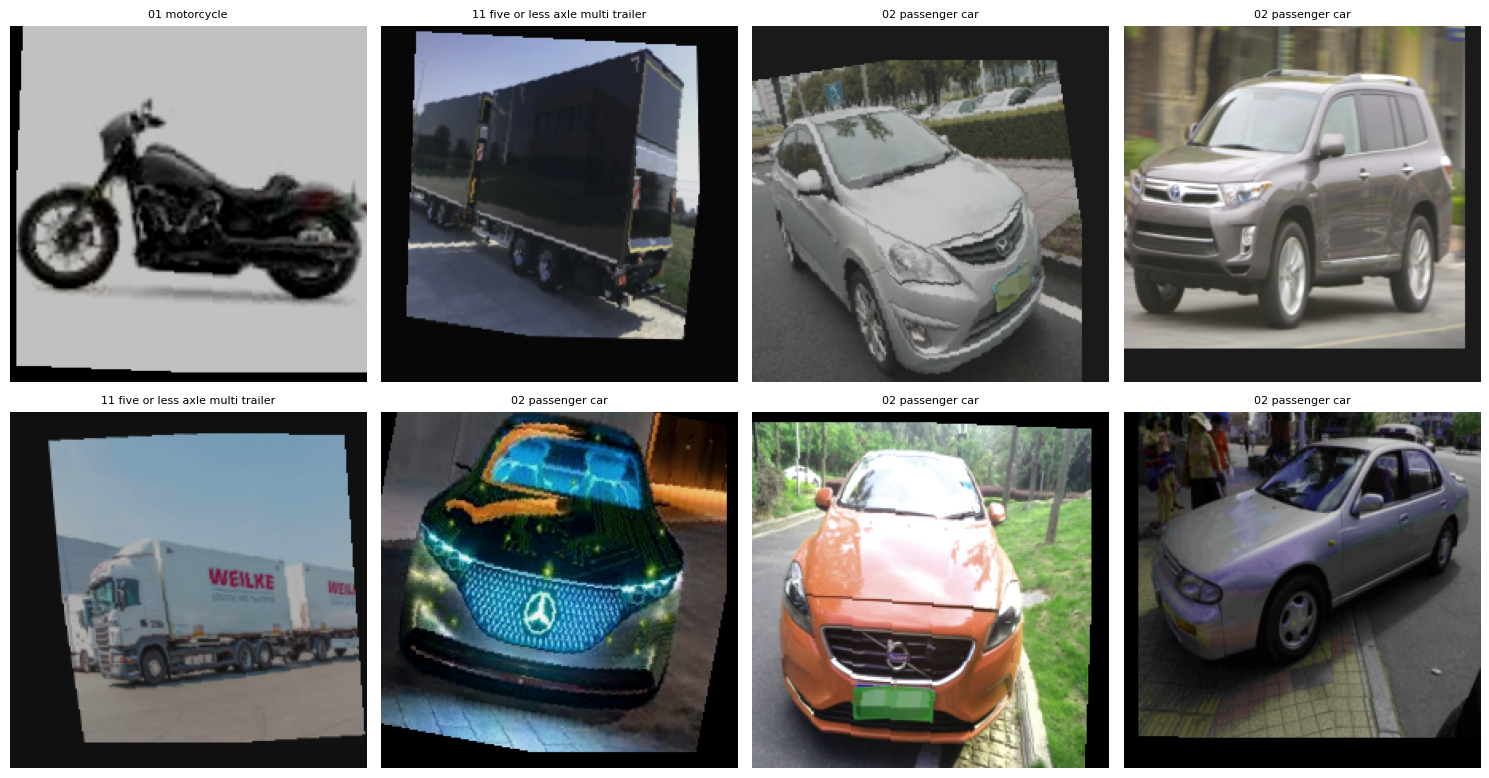

In [32]:
# Cell 5: Visualize Sample Batch
def denormalize(tensor):
    """Denormalize image tensor for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get one batch
images, labels = next(iter(train_loader))

# Plot first 8 images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        class_name = train_dataset.idx_to_class[labels[i].item()]
        ax.set_title(class_name.replace('class_', '').replace('_', ' '), fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / f"sample_batch_{MODEL_TYPE}.png", dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Cell 6: Initialize Transfer Learning Model
if MODEL_TYPE == "resnet18":
    model = VehicleResNet(
        num_classes=NUM_CLASSES, 
        pretrained=True, 
        freeze_backbone=FREEZE_BACKBONE
    )
elif MODEL_TYPE == "resnet34":
    from transfer_model import VehicleResNet34
    model = VehicleResNet34(
        num_classes=NUM_CLASSES, 
        pretrained=True, 
        freeze_backbone=FREEZE_BACKBONE
    )
elif MODEL_TYPE == "efficientnet":
    model = VehicleEfficientNet(
        num_classes=NUM_CLASSES, 
        pretrained=True, 
        freeze_backbone=FREEZE_BACKBONE
    )
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

model = model.to(device)
model.get_num_params()

c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded EfficientNet-B0 (pretrained=True, freeze_backbone=False)
Replaced classifier: 1280 -> 12
Total params: 4,022,920 | Trainable: 4,022,920


4022920

In [34]:
# Cell 7: Loss Function with Class Weights and Label Smoothing
class_weights = compute_class_weights(train_dataset)
print("Class weights:")
for i, weight in enumerate(class_weights):
    print(f"  {train_dataset.idx_to_class[i]}: {weight:.3f}")

class_weights = class_weights.to(device)

# CrossEntropyLoss with class weights AND label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1  # Prevents overconfident predictions
)

print(f"\nLoss Function: CrossEntropyLoss")
print(f"  Class weights: Enabled (handles imbalance)")
print(f"  Label smoothing: 0.1 (prevents overconfidence)")

Class weights:
  class_01_motorcycle: 0.270
  class_02_passenger_car: 0.093
  class_03_four_tire_single_unit: 1.120
  class_04_bus: 0.301
  class_05_two_axle_six_tire_single_unit: 0.915
  class_06_three_axle_single_unit: 0.624
  class_07_four_or_more_axle_single_unit: 1.960
  class_08_four_or_less_axle_single_trailer: 1.247
  class_09_five_axle_tractor_semitrailer: 0.980
  class_10_six_or_more_axle_single_trailer: 1.338
  class_11_five_or_less_axle_multi_trailer: 2.032
  class_13_seven_or_more_axle_multi_trailer: 1.120

Loss Function: CrossEntropyLoss
  Class weights: Enabled (handles imbalance)
  Label smoothing: 0.1 (prevents overconfidence)


In [35]:
# Cell 8: Optimizer with Discriminative Learning Rates
# Separate learning rates: lower for pretrained backbone, higher for new classifier
backbone_params = []
classifier_params = []

# Get backbone and classifier parameters
for name, param in model.named_parameters():
    if 'fc' in name or 'classifier' in name:  # Classifier layers
        classifier_params.append(param)
    else:  # Backbone layers
        backbone_params.append(param)

# Discriminative learning rates
optimizer = optim.Adam([
    {'params': backbone_params, 'lr': LEARNING_RATE * 0.1},  # 10x lower for backbone
    {'params': classifier_params, 'lr': LEARNING_RATE}        # Full LR for classifier
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

print(f"Optimizer: Adam")
print(f"  Backbone LR: {LEARNING_RATE * 0.1} (pretrained layers)")
print(f"  Classifier LR: {LEARNING_RATE} (new layers)")
print(f"Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)")

Optimizer: Adam
  Backbone LR: 0.0001 (pretrained layers)
  Classifier LR: 0.001 (new layers)
Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)


In [36]:
# Cell 9: Create Trainer and Start Training
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    save_dir=OUTPUT_DIR / "checkpoints" / MODEL_TYPE
)

# Train the model
history = trainer.train(num_epochs=NUM_EPOCHS, scheduler=scheduler)

Starting training for 100 epochs...
Device: cuda
Train samples: 1417
Val samples: 322
------------------------------------------------------------


c:\Users\amrem\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/100] Train Loss: 2.4766 | Train Acc: 0.4982 | Val Loss: 2.8245 | Val Acc: 0.7050
  → Best model saved! (Val Acc: 0.7050)
Epoch [2/100] Train Loss: 1.8104 | Train Acc: 0.7339 | Val Loss: 2.7450 | Val Acc: 0.7422
  → Best model saved! (Val Acc: 0.7422)
Epoch [3/100] Train Loss: 1.6174 | Train Acc: 0.7953 | Val Loss: 2.6241 | Val Acc: 0.7888
  → Best model saved! (Val Acc: 0.7888)
Epoch [4/100] Train Loss: 1.4228 | Train Acc: 0.8370 | Val Loss: 2.6255 | Val Acc: 0.7671
Epoch [5/100] Train Loss: 1.3175 | Train Acc: 0.8821 | Val Loss: 2.5619 | Val Acc: 0.8012
  → Best model saved! (Val Acc: 0.8012)
Epoch [6/100] Train Loss: 1.2810 | Train Acc: 0.8984 | Val Loss: 2.5985 | Val Acc: 0.7733
Epoch [7/100] Train Loss: 1.2209 | Train Acc: 0.9097 | Val Loss: 2.5673 | Val Acc: 0.8261
  → Best model saved! (Val Acc: 0.8261)
Epoch [8/100] Train Loss: 1.1591 | Train Acc: 0.9358 | Val Loss: 2.5936 | Val Acc: 0.8168
Epoch [9/100] Train Loss: 1.1461 | Train Acc: 0.9301 | Val Loss: 2.5109 | Val Ac

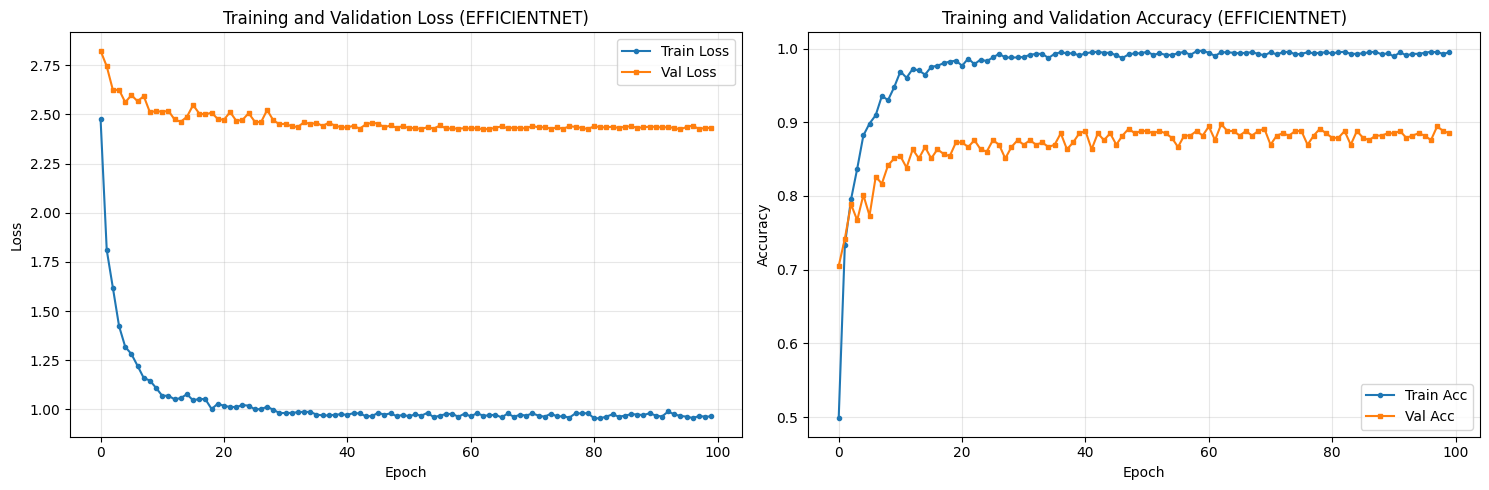

Best validation accuracy: 0.8975


In [37]:
# Cell 10: Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax1.plot(history['val_loss'], label='Val Loss', marker='s', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title(f'Training and Validation Loss ({MODEL_TYPE.upper()})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', marker='o', markersize=3)
ax2.plot(history['val_acc'], label='Val Acc', marker='s', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title(f'Training and Validation Accuracy ({MODEL_TYPE.upper()})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / f"training_history_{MODEL_TYPE}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {trainer.best_val_acc:.4f}")

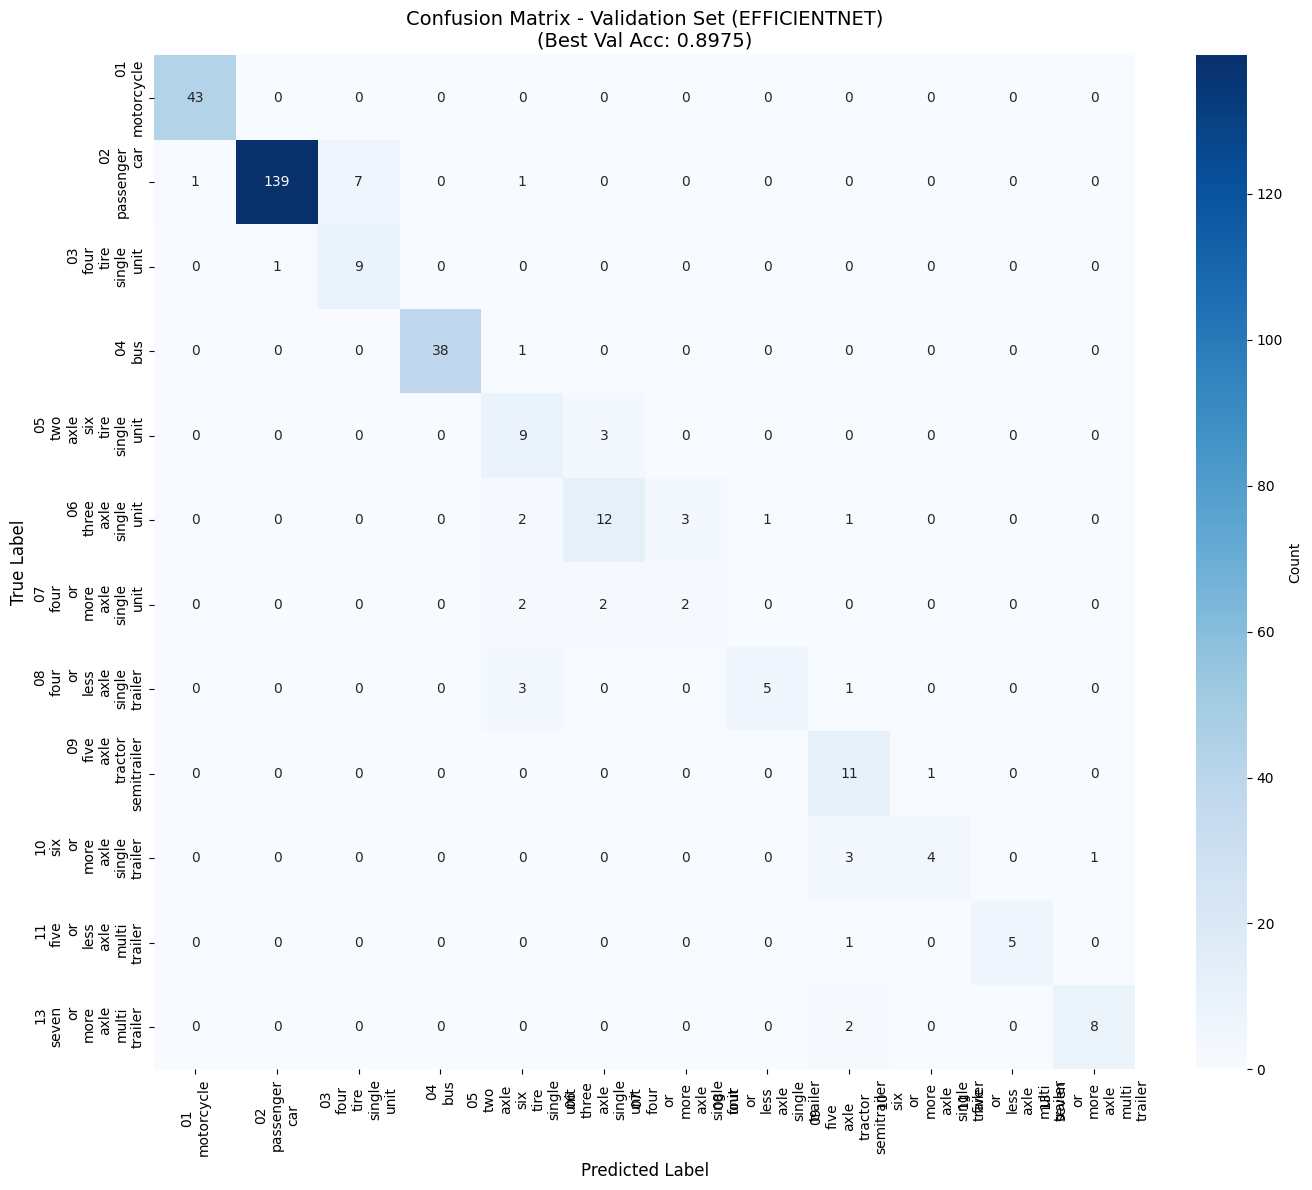


Classification Report (Validation Set):
                                     precision    recall  f1-score   support

                      01 motorcycle     0.9773    1.0000    0.9885        43
                   02 passenger car     0.9929    0.9392    0.9653       148
           03 four tire single unit     0.5625    0.9000    0.6923        10
                             04 bus     1.0000    0.9744    0.9870        39
   05 two axle six tire single unit     0.5000    0.7500    0.6000        12
          06 three axle single unit     0.7059    0.6316    0.6667        19
   07 four or more axle single unit     0.4000    0.3333    0.3636         6
08 four or less axle single trailer     0.8333    0.5556    0.6667         9
   09 five axle tractor semitrailer     0.5789    0.9167    0.7097        12
 10 six or more axle single trailer     0.8000    0.5000    0.6154         8
 11 five or less axle multi trailer     1.0000    0.8333    0.9091         6
13 seven or more axle multi traile

In [38]:
# Cell 11: Generate Confusion Matrix on Validation Set
def get_predictions(model, data_loader, device):
    """Get all predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

# Get predictions
val_preds, val_labels = get_predictions(model, val_loader, device)

# Compute confusion matrix
cm = confusion_matrix(val_labels, val_preds)

# Plot confusion matrix
plt.figure(figsize=(14, 12))
class_names = [name.replace('class_', '').replace('_', '\n') for name in val_dataset.idx_to_class.values()]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Validation Set ({MODEL_TYPE.upper()})\n(Best Val Acc: {trainer.best_val_acc:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / f"confusion_matrix_val_{MODEL_TYPE}.png", dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("\nClassification Report (Validation Set):")
print("="*70)
target_names = [name.replace('class_', '').replace('_', ' ') for name in val_dataset.idx_to_class.values()]
print(classification_report(val_labels, val_preds, target_names=target_names, digits=4))

FINAL EVALUATION ON TEST SET
Found 334 images in 12 classes
Test samples: 334

Test Accuracy: 0.8623


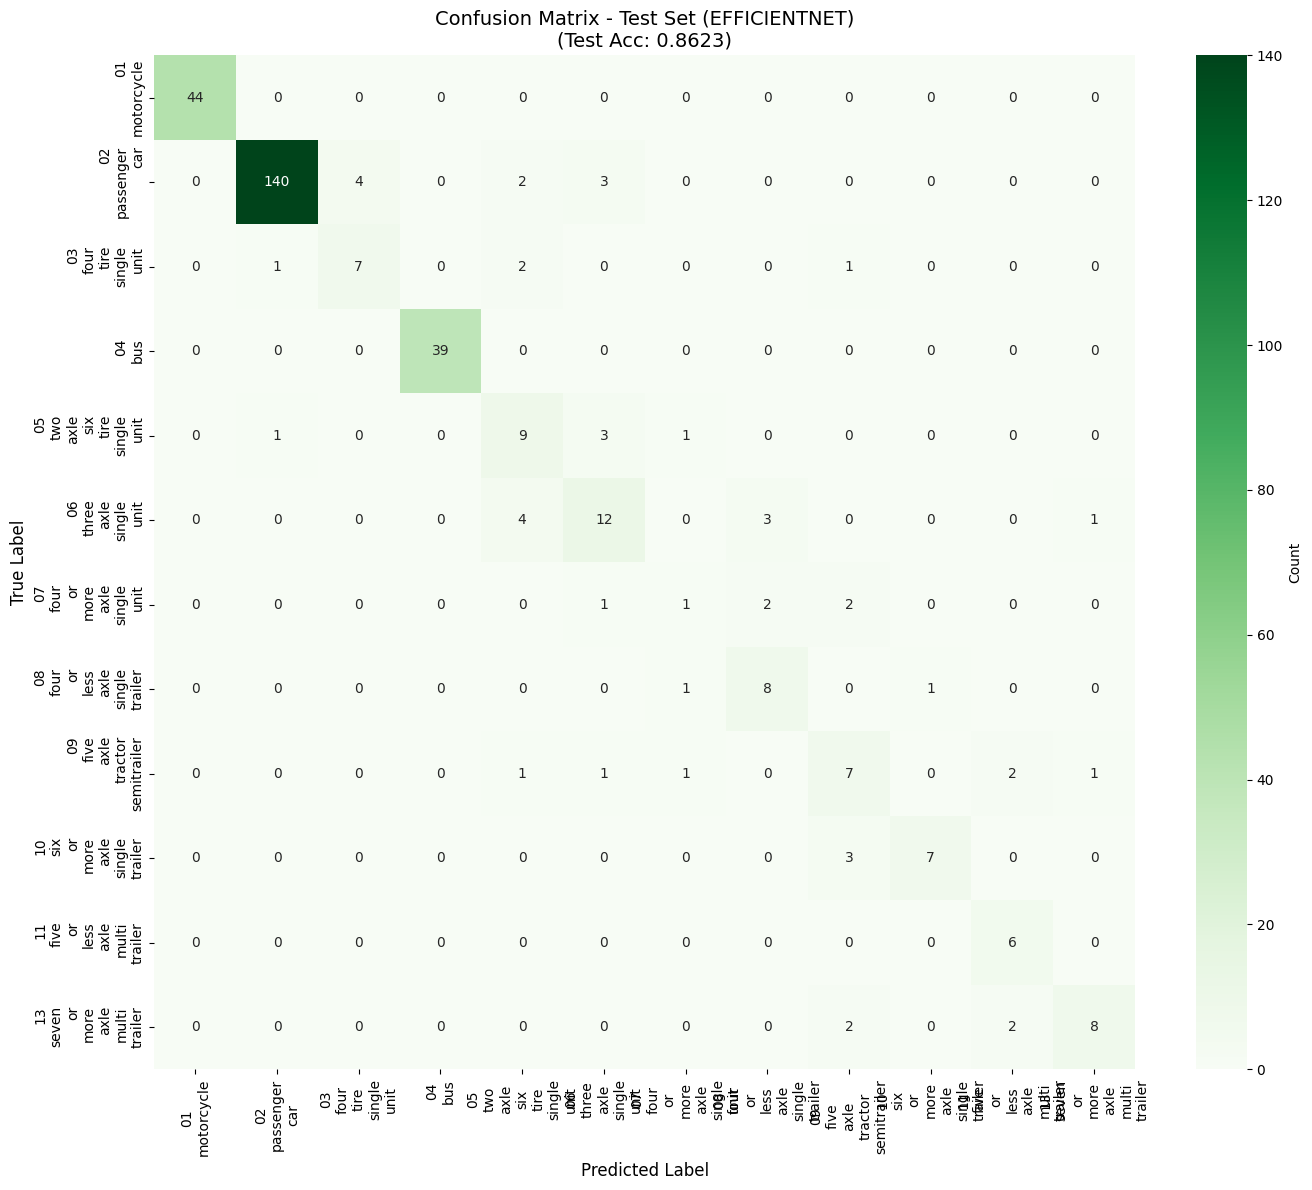


Classification Report (Test Set):
                                     precision    recall  f1-score   support

                      01 motorcycle     1.0000    1.0000    1.0000        44
                   02 passenger car     0.9859    0.9396    0.9622       149
           03 four tire single unit     0.6364    0.6364    0.6364        11
                             04 bus     1.0000    1.0000    1.0000        39
   05 two axle six tire single unit     0.5000    0.6429    0.5625        14
          06 three axle single unit     0.6000    0.6000    0.6000        20
   07 four or more axle single unit     0.2500    0.1667    0.2000         6
08 four or less axle single trailer     0.6154    0.8000    0.6957        10
   09 five axle tractor semitrailer     0.4667    0.5385    0.5000        13
 10 six or more axle single trailer     0.8750    0.7000    0.7778        10
 11 five or less axle multi trailer     0.6000    1.0000    0.7500         6
13 seven or more axle multi trailer     

In [39]:
# Cell 12: Evaluate on Test Set
print("="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

# Load test dataset
test_transform = get_transforms('test', img_size=IMG_SIZE)
test_dataset = VehicleDataset(TEST_DIR, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")

# Get predictions on test set
test_preds, test_labels = get_predictions(model, test_loader, device)

# Compute test accuracy
test_accuracy = (test_preds == test_labels).mean()
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# Confusion matrix for test set
cm_test = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - Test Set ({MODEL_TYPE.upper()})\n(Test Acc: {test_accuracy:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / f"confusion_matrix_test_{MODEL_TYPE}.png", dpi=150, bbox_inches='tight')
plt.show()

# Classification report for test set
print("\nClassification Report (Test Set):")
print("="*70)
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))